In [ ]:
!pip install arch

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import poisson, nbinom, levene
import statsmodels.api as sm
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

------------------------------
--- SUMMARY STATISTICS (WTI Crude Oil) ---
Total Years Analyzed: 40
Hit Ratio (Positive Years): 62.5%
Historical CAGR: 4.51%
Global Mean Return: 10.38%
------------------------------


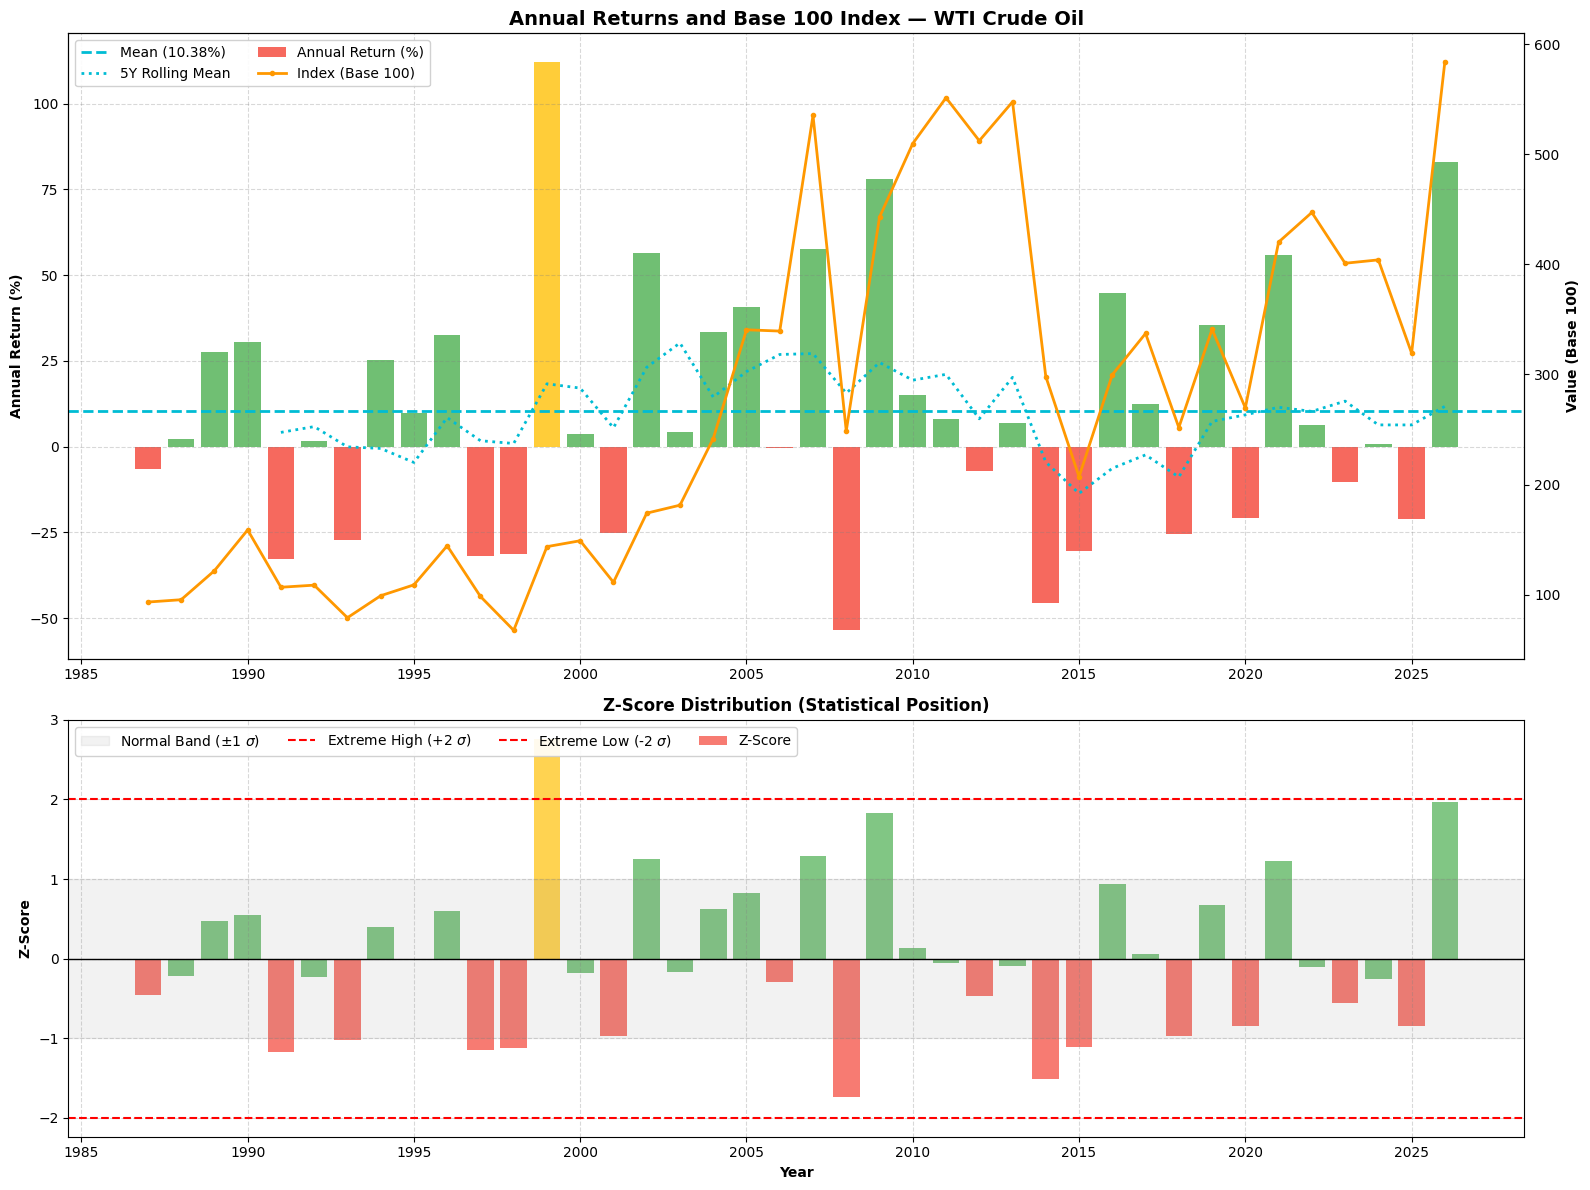

In [ ]:
# Z-SCORE Analysis
ticker = "WTI Crude Oil"
file_path = "wti_crude_oil_historical.csv"

# Robust Data Ingestion
df = pd.read_csv(file_path, na_values=".")
df.rename(columns={'DATE': 'Date', 'DCOILWTICO': 'Close'}, inplace=True)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.dropna(subset=['Close'], inplace=True)
df = df[df['Close'] > 0]
df = df.sort_index()

# Daily Returns
df['Returns'] = df['Close'].pct_change()
df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
df['Abs_Returns'] = df['Returns'].abs()
df.dropna(subset=['Returns', 'Log_Returns'], inplace=True)

# Annual Aggregation
df_annual = df['Close'].resample('YE').last().to_frame()
df_annual['Annual_Return'] = df_annual['Close'].pct_change()
df_annual = df_annual.dropna()
df_annual['Year'] = df_annual.index.year
df_annual.set_index('Year', inplace=True)

# Performance Metrics
df_annual['Base_100'] = 100 * (1 + df_annual['Annual_Return']).cumprod()
df_annual['5Y_Mean'] = df_annual['Annual_Return'].rolling(window=5).mean()

# Z-Score Calculation
global_mean = df_annual['Annual_Return'].mean()
global_std = df_annual['Annual_Return'].std()
df_annual['Z_Score'] = (df_annual['Annual_Return'] - global_mean) / global_std
df_annual['Outlier'] = df_annual['Z_Score'].abs() >= 2

# Summary Statistics
positive_years = (df_annual['Annual_Return'] > 0).sum()
total_years = len(df_annual)
hit_ratio = (positive_years / total_years) * 100
cagr = ((df_annual['Base_100'].iloc[-1] / 100) ** (1 / total_years) - 1) * 100

print("-" * 30)
print(f"--- SUMMARY STATISTICS ({ticker}) ---")
print(f"Total Years Analyzed: {total_years}")
print(f"Hit Ratio (Positive Years): {hit_ratio:.1f}%")
print(f"Historical CAGR: {cagr:.2f}%")
print(f"Global Mean Return: {global_mean*100:.2f}%")
print("-" * 30)

# Plotting
fig, (ax1, ax_z) = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [1.5, 1]})

colors = ['#ffc107' if row['Outlier'] else '#4caf50' if row['Annual_Return'] >= 0 else '#f44336' for _, row in df_annual.iterrows()]

# Top Panel: Returns and Base 100
ax1.bar(df_annual.index, df_annual['Annual_Return'] * 100, color=colors, alpha=0.8, label='Annual Return (%)')
ax1.axhline(global_mean * 100, color='#00bcd4', linestyle='--', linewidth=2, label=f'Mean ({global_mean*100:.2f}%)')
ax1.plot(df_annual.index, df_annual['5Y_Mean'] * 100, color='#00bcd4', linestyle=':', linewidth=2, label='5Y Rolling Mean')
ax1.set_ylabel('Annual Return (%)', fontweight='bold')
ax1.set_title(f"Annual Returns and Base 100 Index — {ticker}", fontsize=14, fontweight='bold')
ax1.grid(color='gray', linestyle='--', alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df_annual.index, df_annual['Base_100'], color='#ff9800', marker='.', linewidth=2, label='Index (Base 100)')
ax2.set_ylabel('Value (Base 100)', fontweight='bold')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', ncol=2, facecolor='white', framealpha=0.9)

# Bottom Panel: Z-Score
ax_z.bar(df_annual.index, df_annual['Z_Score'], color=colors, alpha=0.7, label='Z-Score')
ax_z.axhspan(-1, 1, color='gray', alpha=0.1, label='Normal Band (±1 $\sigma$)')
ax_z.axhline(2, color='red', linestyle='--', linewidth=1.5, label='Extreme High (+2 $\sigma$)')
ax_z.axhline(-2, color='red', linestyle='--', linewidth=1.5, label='Extreme Low (-2 $\sigma$)')
ax_z.axhline(0, color='black', linewidth=1)

ax_z.set_ylabel('Z-Score', fontweight='bold')
ax_z.set_xlabel('Year', fontweight='bold')
ax_z.set_title("Z-Score Distribution (Statistical Position)", fontsize=12, fontweight='bold')
ax_z.legend(loc='upper left', ncol=4, facecolor='white', framealpha=0.9)
ax_z.grid(color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

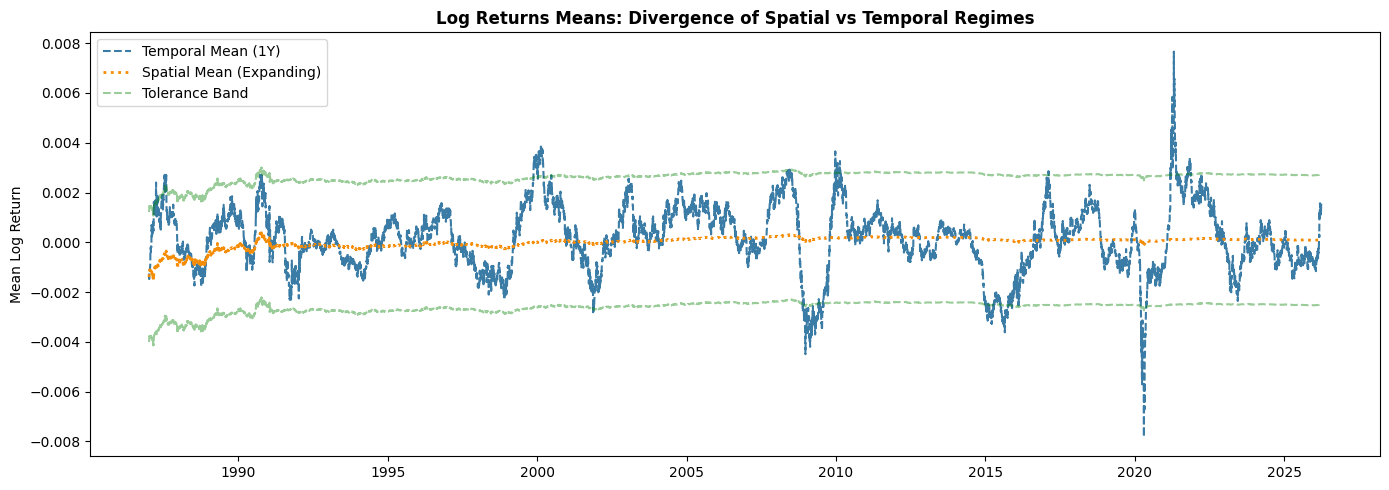

In [ ]:
# ERGODICITY check
ROLLING_DAYS = 252 # Approx. 1 trading year

df['Rolling_Mean'] = df['Log_Returns'].rolling(window=ROLLING_DAYS).mean()
df['Expanding_Mean'] = df['Log_Returns'].expanding().mean()
df['Difference'] = df['Rolling_Mean'] - df['Expanding_Mean']

df_clean = df.dropna(subset=['Rolling_Mean', 'Expanding_Mean']).copy()
threshold_value = 2.0 * df_clean['Difference'].std()
df_clean['Non_Ergodic'] = df_clean['Difference'].abs() > threshold_value

# Plotting Ergodicity Divergence
fig, ax_means = plt.subplots(figsize=(14, 5))
ax_means.plot(df_clean.index, df_clean['Rolling_Mean'], color='#3a7ca5', linestyle='--', label='Temporal Mean (1Y)')
ax_means.plot(df_clean.index, df_clean['Expanding_Mean'], color='#f48c06', linestyle=':', linewidth=2, label='Spatial Mean (Expanding)')
ax_means.plot(df_clean.index, df_clean['Expanding_Mean'] + threshold_value, color='green', linestyle='--', alpha=0.4, label='Tolerance Band')
ax_means.plot(df_clean.index, df_clean['Expanding_Mean'] - threshold_value, color='green', linestyle='--', alpha=0.4)
ax_means.set_title("Log Returns Means: Divergence of Spatial vs Temporal Regimes", fontweight='bold')
ax_means.set_ylabel('Mean Log Return')
ax_means.legend()
plt.tight_layout()
plt.show()

--- OVERDISPERSION CHECK ---
Empirical Mean (λ):  4.62
Empirical Variance: 13.09
Variance/Mean Ratio: 2.83 (Poisson strictly requires 1.0)
Generating Distribution Fit Diagnostics...


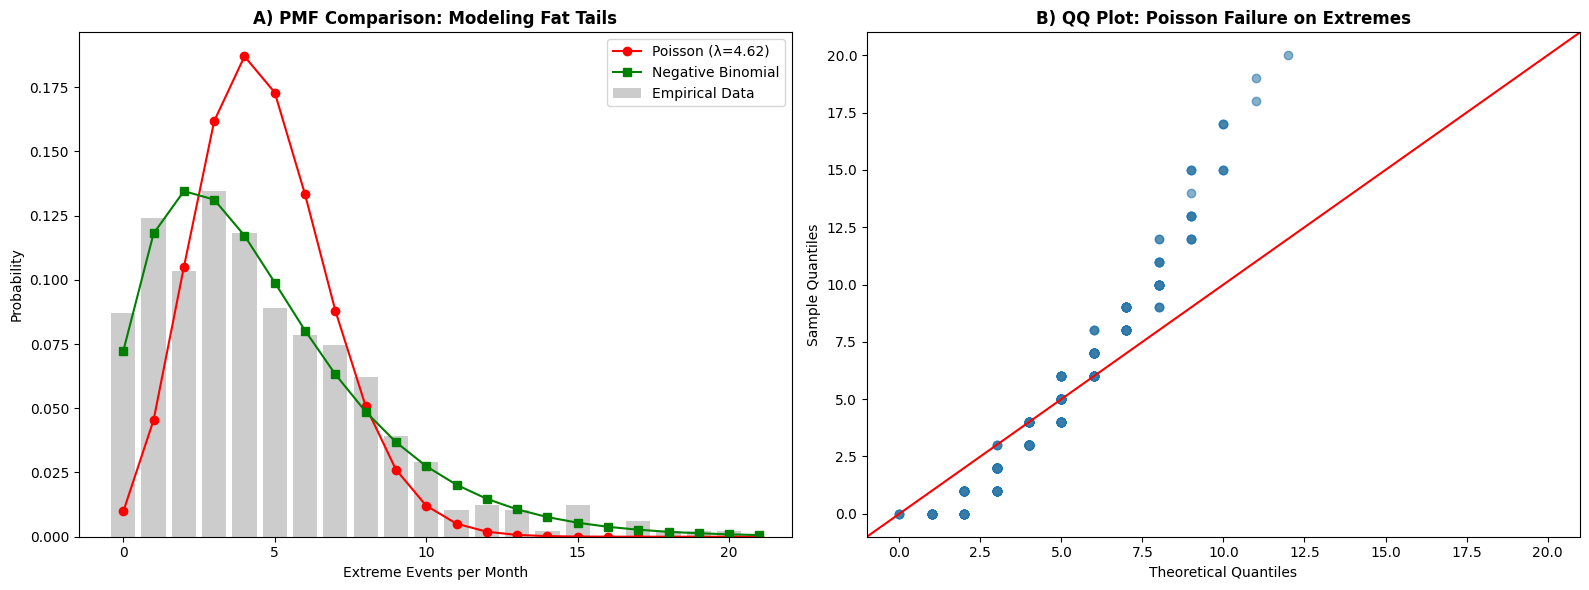

In [ ]:
# Distribution Analysis (POISSON VS NBINOM)
EVENT_THRESHOLD = 0.025
df['Event'] = (df['Abs_Returns'] >= EVENT_THRESHOLD).astype(int)

monthly_data = df.resample('ME').agg(
    Events_per_Month=('Event', 'sum'),
    Close_Price=('Close', 'last')
)
monthly_data['Log_Price'] = np.log(monthly_data['Close_Price'])
monthly_data = monthly_data.dropna()

mu = monthly_data['Events_per_Month'].mean()
var = monthly_data['Events_per_Month'].var()

print("--- OVERDISPERSION CHECK ---")
print(f"Empirical Mean (\u03bb):  {mu:.2f}")
print(f"Empirical Variance: {var:.2f}")
print(f"Variance/Mean Ratio: {var/mu:.2f} (Poisson strictly requires 1.0)")

# Calculate Negative Binomial parameters for comparison
p_nb = mu / var
n_nb = (mu**2) / (var - mu) if var > mu else 0

print("Generating Distribution Fit Diagnostics...")

fig_diag, (ax_pmf, ax_qq) = plt.subplots(1, 2, figsize=(16, 6))

# PMF Comparison
max_events = int(monthly_data['Events_per_Month'].max())
x_vals = np.arange(0, max_events + 2)

emp_counts = monthly_data['Events_per_Month'].value_counts(normalize=True).sort_index()
ax_pmf.bar(emp_counts.index, emp_counts.values, color='gray', alpha=0.4, label='Empirical Data')

# Poisson Curve
ax_pmf.plot(x_vals, poisson.pmf(x_vals, mu), color='red', marker='o', label=f'Poisson (\u03bb={mu:.2f})')

# Negative Binomial Curve
if var > mu:
    ax_pmf.plot(x_vals, nbinom.pmf(x_vals, n_nb, p_nb), color='green', marker='s', label='Negative Binomial')

ax_pmf.set_title('A) PMF Comparison: Modeling Fat Tails', fontweight='bold')
ax_pmf.set_xlabel('Extreme Events per Month')
ax_pmf.set_ylabel('Probability')
ax_pmf.legend()

# --- B) QQ Plot (Poisson Baseline) ---
sm.qqplot(monthly_data['Events_per_Month'], dist=poisson(mu), line='45', ax=ax_qq, markerfacecolor='#3a7ca5', alpha=0.6)
ax_qq.set_title('B) QQ Plot: Poisson Failure on Extremes', fontweight='bold')

plt.tight_layout()
plt.show()


Estimating Conditional Volatility (GARCH 1,1)...
GARCH Alpha (Shock impact): 0.1084
GARCH Beta (Persistence): 0.8839
Total Persistence: 0.9923

--- THE PHYSICAL LIMIT ---
99th Percentile Calculated Threshold: 16 extreme events/month


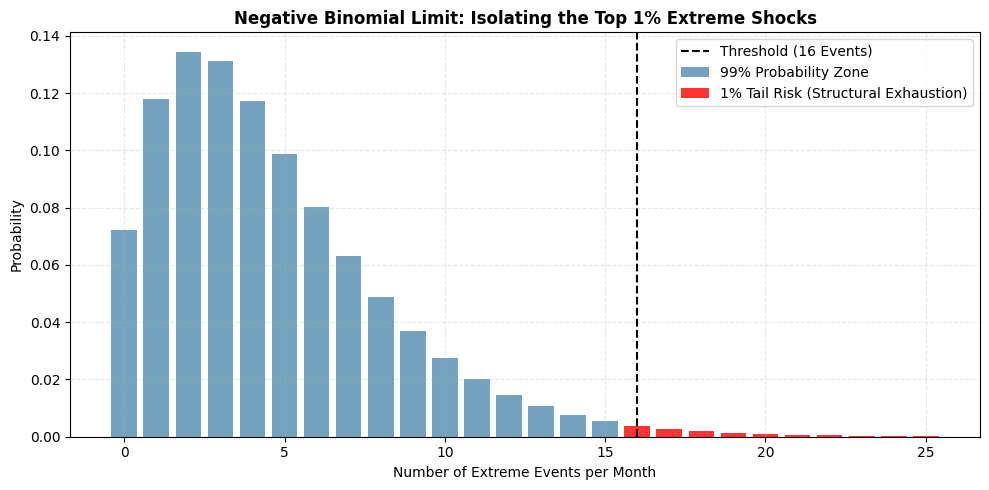

In [ ]:
# Garch Volatility
print("\nEstimating Conditional Volatility (GARCH 1,1)...")
returns_garch = df['Log_Returns'].dropna() * 100
am = arch_model(returns_garch, vol='Garch', p=1, q=1, dist='Normal')
res = am.fit(disp='off')
df['Conditional_Vol'] = (res.conditional_volatility / 100) * np.sqrt(252)
print(f"GARCH Alpha (Shock impact): {res.params['alpha[1]']:.4f}")
print(f"GARCH Beta (Persistence): {res.params['beta[1]']:.4f}")
print(f"Total Persistence: {res.params['alpha[1]'] + res.params['beta[1]']:.4f}")
monthly_garch = df['Conditional_Vol'].resample('ME').mean()
monthly_data['Avg_GARCH_Vol'] = monthly_garch

# Negative Binomial Threshold Calculation
p_nb = mu / var
n_nb = (mu**2) / (var - mu)
stat_threshold = nbinom.ppf(0.99, n_nb, p_nb)
TARGET_THRESHOLD = int(stat_threshold)

print(f"\n--- THE PHYSICAL LIMIT ---")
print(f"99th Percentile Calculated Threshold: {TARGET_THRESHOLD} extreme events/month")

# Tail Risk visualization
fig, ax_tail = plt.subplots(figsize=(10, 5))

x_tail = np.arange(0, TARGET_THRESHOLD + 10)
pmf_tail = nbinom.pmf(x_tail, n_nb, p_nb)

ax_tail.bar(x_tail[x_tail < TARGET_THRESHOLD], pmf_tail[x_tail < TARGET_THRESHOLD], color='#3a7ca5', alpha=0.7, label='99% Probability Zone')
ax_tail.bar(x_tail[x_tail >= TARGET_THRESHOLD], pmf_tail[x_tail >= TARGET_THRESHOLD], color='red', alpha=0.8, label='1% Tail Risk (Structural Exhaustion)')
ax_tail.axvline(TARGET_THRESHOLD, color='black', linestyle='--', linewidth=1.5, label=f'Threshold ({TARGET_THRESHOLD} Events)')
ax_tail.set_title("Negative Binomial Limit: Isolating the Top 1% Extreme Shocks", fontweight='bold')
ax_tail.set_xlabel('Number of Extreme Events per Month')
ax_tail.set_ylabel('Probability')
ax_tail.legend()
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

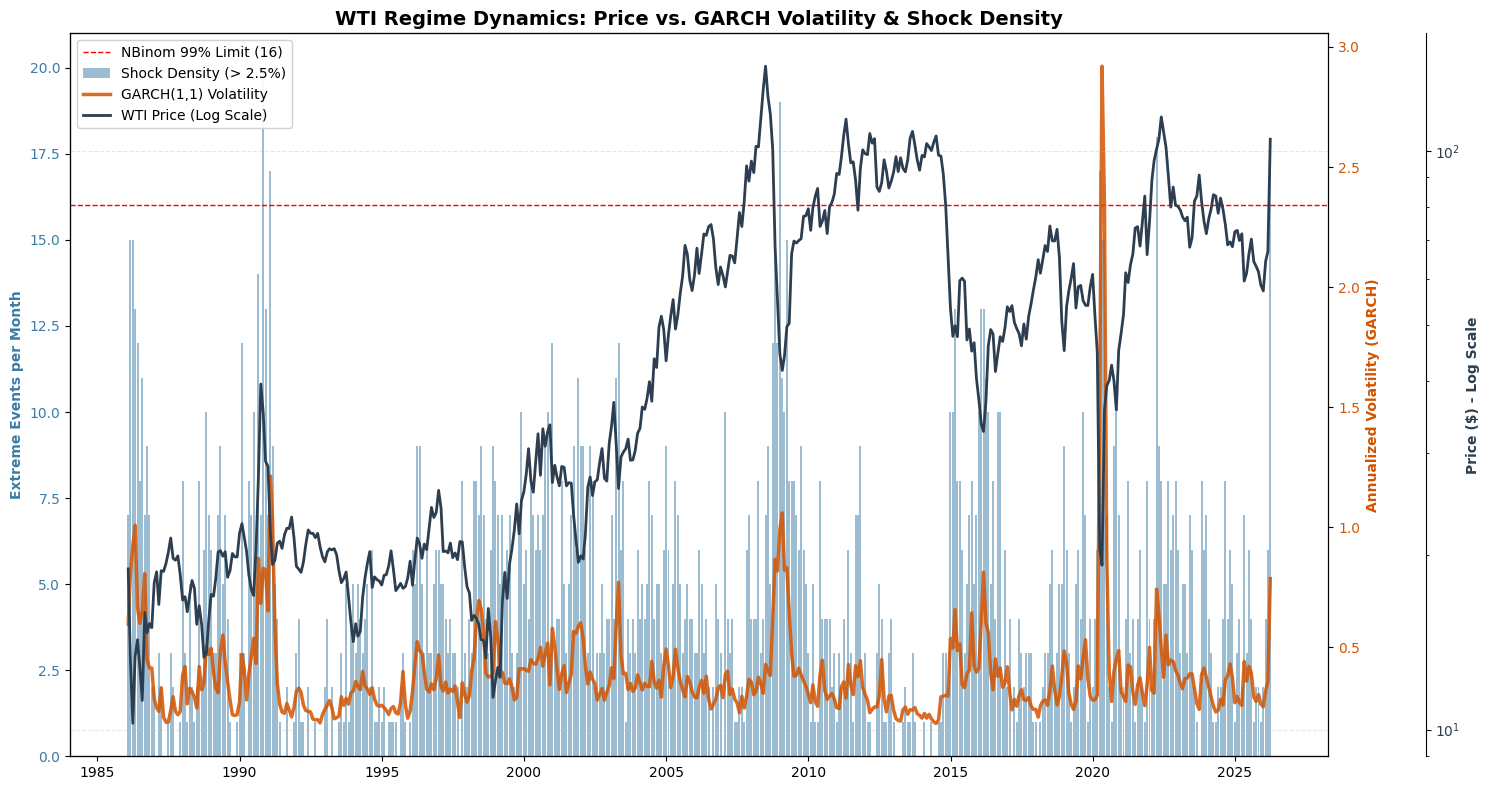

In [ ]:
# WTI REGIME DYNAMICS

# Absolute guarantee that GARCH data exists
if 'Avg_GARCH_Vol' not in monthly_data.columns:
    print("System check: GARCH data missing")
    # Check if the daily GARCH is also missing
    if 'Conditional_Vol' not in df.columns:
        returns_garch = df['Log_Returns'].dropna() * 100
        am = arch_model(returns_garch, vol='Garch', p=1, q=1, dist='Normal')
        res = am.fit(disp='off')
        df['Conditional_Vol'] = (res.conditional_volatility / 100) * np.sqrt(252)

    # Aggregate and clean
    monthly_data['Avg_GARCH_Vol'] = df['Conditional_Vol'].resample('ME').mean()
    monthly_data = monthly_data.dropna()
    print("System check: GARCH restored. Generating chart...")
# -------------------------------------------------------------------

# Ensure TARGET_THRESHOLD exists (fallback to 16 if Block 7 was skipped)
if 'TARGET_THRESHOLD' not in locals():
    TARGET_THRESHOLD = 16

fig, ax1 = plt.subplots(figsize=(15, 8))

# Event Density (Bars)
ax1.bar(monthly_data.index, monthly_data['Events_per_Month'], color='#3a7ca5', alpha=0.5, width=25, label='Shock Density (> 2.5%)')
ax1.axhline(TARGET_THRESHOLD, color='red', linestyle='--', linewidth=1, label=f'NBinom 99% Limit ({TARGET_THRESHOLD})')
ax1.set_ylabel('Extreme Events per Month', color='#3a7ca5', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#3a7ca5')

# GARCH Volatility (Right Axis 1)
ax_garch = ax1.twinx()
ax_garch.plot(monthly_data.index, monthly_data['Avg_GARCH_Vol'], color='#d35400', linewidth=2.5, alpha=0.85, label='GARCH(1,1) Volatility')
ax_garch.set_ylabel('Annualized Volatility (GARCH)', color='#d35400', fontweight='bold')
ax_garch.tick_params(axis='y', labelcolor='#d35400')

# WTI Price (Right Axis 2 - Offset)
ax_price = ax1.twinx()
ax_price.spines['right'].set_position(('outward', 70))
ax_price.plot(monthly_data.index, monthly_data['Close_Price'], color='#2c3e50', linewidth=2, label='WTI Price (Log Scale)')
ax_price.set_yscale('log')
ax_price.set_ylabel('Price ($) - Log Scale', color='#2c3e50', fontweight='bold')
ax_price.tick_params(axis='y', labelcolor='#2c3e50')

# Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_g, labels_g = ax_garch.get_legend_handles_labels()
lines_p, labels_p = ax_price.get_legend_handles_labels()
ax1.legend(lines_1 + lines_g + lines_p, labels_1 + labels_g + labels_p, loc='upper left', facecolor='white', framealpha=0.9)

plt.title("WTI Regime Dynamics: Price vs. GARCH Volatility & Shock Density", fontweight='bold', fontsize=14)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
#  ANALYSIS OF THE "16-EVENT IMPACT"

impact_results = []

for month in exhaustion_months:
    # Z-Score volatility
    current_vol = df['Conditional_Vol'].loc[:month].iloc[-1]
    hist_vol_mean = df['Conditional_Vol'].loc[:month].mean()
    hist_vol_std = df['Conditional_Vol'].loc[:month].std()
    vol_z_score = (current_vol - hist_vol_mean) / hist_vol_std

    # Price slope (last 5 days)
    price_slice = df['Close'].loc[:month].tail(5)
    x_impact = np.arange(len(price_slice))
    slope_impact, _, _, _, _ = stats.linregress(x_impact, price_slice.values)

    impact_results.append(vol_z_score)

    print(f"[{month.date()}] Volatility Z-Score: {vol_z_score:.2f} \u03c3 | Price Slope (5d): {slope_impact:.4f}")

print("-" * 30)
print(f"Average Volatility Tension at Signal: {np.mean(impact_results):.2f} \u03c3")

[1990-10-31] Volatility Z-Score: 2.93 σ | Price Slope (5d): 0.3820
[1991-01-31] Volatility Z-Score: 4.60 σ | Price Slope (5d): -0.4450
[2008-12-31] Volatility Z-Score: 4.10 σ | Price Slope (5d): 2.4690
[2020-03-31] Volatility Z-Score: 9.93 σ | Price Slope (5d): -0.2980
[2022-03-31] Volatility Z-Score: 1.43 σ | Price Slope (5d): -3.1080
[2026-03-31] Volatility Z-Score: 1.89 σ | Price Slope (5d): 3.2770
------------------------------
Average Volatility Tension at Signal: 4.15 σ


In [ ]:
# VULNERABILITY ANALYSIS: THE MEDIAN RECOVERY

recovery_days = []
TARGET_CRUSH = 0.25 # Volatility drops 25% from peak

for month in exhaustion_months:
    peak_vol = df['Conditional_Vol'].loc[:month].iloc[-1]
    # 60 following days
    post_signal_data = df['Conditional_Vol'].loc[month:].iloc[1:].head(60)

    if post_signal_data.empty:
        print(f"[{month.date()}] Ongoing Shock: Data pending for 2026...")
        continue

    # Day of drop (25%)
    days_to_settle = (post_signal_data <= peak_vol * (1 - TARGET_CRUSH)).idxmax()

    if (post_signal_data <= peak_vol * (1 - TARGET_CRUSH)).any():
        diff = (days_to_settle - month).days
        trading_days = len(df.loc[month:days_to_settle])
        recovery_days.append(trading_days)
        print(f"[{month.date()}] Shock Absorption: {trading_days} trading days")
    else:
        print(f"[{month.date()}] Persistent Trauma: >60 days")


if recovery_days:
    final_median = np.median(recovery_days)
    print("-" * 30)
    print(f"RESULT: MEDIAN VULNERABILITY WINDOW = {final_median:.1f} DAYS")

[1990-10-31] Shock Absorption: 14 trading days
[1991-01-31] Shock Absorption: 7 trading days
[2008-12-31] Shock Absorption: 24 trading days
[2020-03-31] Shock Absorption: 38 trading days
[2022-03-31] Shock Absorption: 19 trading days
[2026-03-31] Ongoing Shock: Data pending for 2026...
------------------------------
RESULT: MEDIAN VULNERABILITY WINDOW = 19.0 DAYS
